正在讀取 訓練集 (rehab_dataset_keyframes_train_xyz.csv)...
正在讀取 驗證集 (rehab_dataset_keyframes_val_xyz.csv)...
正在讀取 測試集 (rehab_dataset_keyframes_test_xyz.csv)...

資料載入完成:
Training: (25290, 63), Validation: (226, 63), Testing: (138, 63)

正在進行訓練集數據增強 (加入雜訊)...
增強後訓練集筆數: 50580

開始訓練...
Epoch 1/100
791/791 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7502 - loss: 0.6272 - val_accuracy: 0.8142 - val_loss: 0.5767
Epoch 2/100
791/791 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9260 - loss: 0.1993 - val_accuracy: 0.8584 - val_loss: 0.5503
Epoch 3/100
791/791 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9554 - loss: 0.1213 - val_accuracy: 0.8982 - val_loss: 0.4819
Epoch 4/100
791/791 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9673 - loss: 0.0900 - val_accuracy: 0.8186 - val_loss: 0.8550
Epoch 5/100
791/791 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9733 - loss: 0.0728 - val_accuracy: 0.8451 - val_loss: 0.7172
Epoch 6/100
791/791 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9741 - loss: 

訓練完成！模型已儲存為: rehab_action_classifier_clear_1.h5

正在使用測試集 (Test Set) 進行最終評估...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

--- 分類報告 (Classification Report) ---
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        21
           1     1.0000    0.6875    0.8148        16
           2     1.0000    1.0000    1.0000        17
           3     0.8571    1.0000    0.9231        18
           4     1.0000    1.0000    1.0000        17
           5     0.8077    0.8750    0.8400        24
           6     1.0000    1.0000    1.0000        25

    accuracy                         0.9420       138
   macro avg     0.9521    0.9375    0.9397       138
weighted avg     0.9479    0.9420    0.9407       138



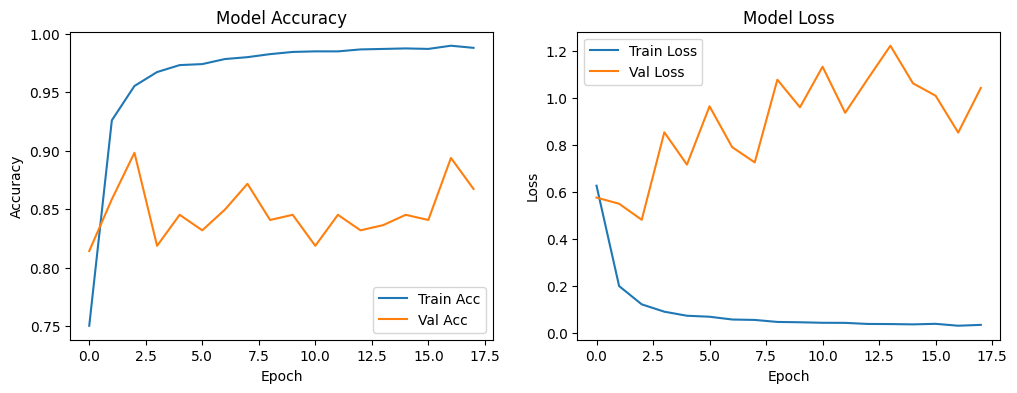

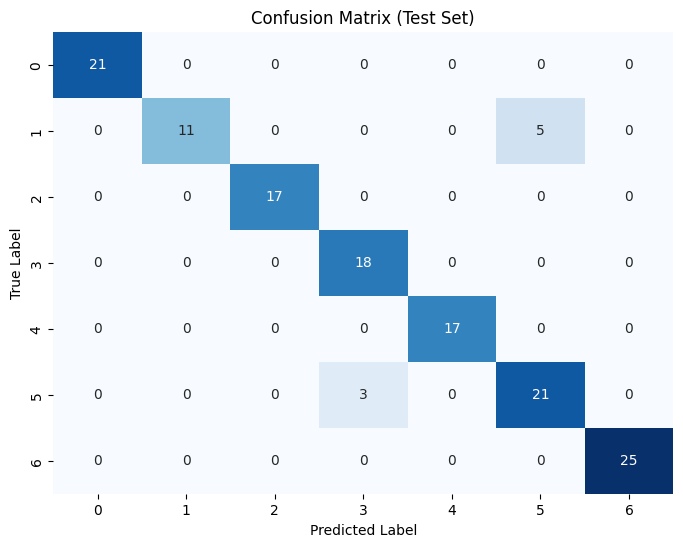

In [4]:
import os
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ==========================================
# 1. 設定檔案路徑 (請確認這裡的檔名與你產生的檔案一致)
# ==========================================
TRAIN_DATA_PATH = 'rehab_dataset_keyframes_train_xyz.csv'
VAL_DATA_PATH   = 'rehab_dataset_keyframes_val_xyz.csv'
TEST_DATA_PATH  = 'rehab_dataset_keyframes_test_xyz.csv'

MODEL_SAVE_PATH = 'rehab_action_classifier_clear_1.h5'
NUM_CLASSES = 7

# 定義讀取資料的函式 (避免重複寫三次程式碼)
def load_dataset(path, name="Dataset"):
    if not os.path.exists(path):
        print(f"錯誤：找不到檔案 {path}")
        exit()
    
    print(f"正在讀取 {name} ({path})...")
    df = pd.read_csv(path, header=None)
    
    # 前 63 欄是特徵 (21點 * 3軸)，最後一欄是 Label
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values.astype(int) # 確保是整數
    
    # 修正標籤：如果是 1~7，轉成 0~6
    if np.min(y) == 1:
        y = y - 1
        
    return X, y

# ==========================================
# 2. 讀取資料
# ==========================================
X_train, y_train = load_dataset(TRAIN_DATA_PATH, "訓練集")
X_val, y_val     = load_dataset(VAL_DATA_PATH,   "驗證集")
X_test, y_test   = load_dataset(TEST_DATA_PATH,  "測試集")

print(f"\n資料載入完成:")
print(f"Training: {X_train.shape}, Validation: {X_val.shape}, Testing: {X_test.shape}")

# ==========================================
# 3. 數據增強 (只對訓練集做！)
# ==========================================
print("\n正在進行訓練集數據增強 (加入雜訊)...")

def add_noise(data, noise_level=0.02):
    noise = np.random.normal(0, noise_level, data.shape)
    return data + noise

# 擴充訓練資料：原始 + 加雜訊版本
X_train_noise = add_noise(X_train)
X_train_augmented = np.vstack((X_train, X_train_noise))
y_train_augmented = np.concatenate((y_train, y_train))

# 驗證集 (Val) 和 測試集 (Test) 不需要增強，保持原樣以反應真實情況

print(f"增強後訓練集筆數: {len(X_train_augmented)}")

# ==========================================
# 4. 建立模型
# ==========================================
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((63, )),
    tf.keras.layers.Dense(256, activation='relu'), 
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ==========================================
# 5. 開始訓練
# ==========================================
print("\n開始訓練...")

history = model.fit(
    X_train_augmented, y_train_augmented,  # 訓練用增強後的資料
    epochs=100,
    batch_size=64,
    validation_data=(X_val, y_val),        # 驗證用純淨的 Validation Set
    callbacks=[
        # 當 Validation Loss 連續 15 次沒下降就停止，並回朔到最好的參數
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', 
            patience=15, 
            verbose=1, 
            restore_best_weights=True
        )
    ]
)

# 儲存模型
model.save(MODEL_SAVE_PATH)
print(f"訓練完成！模型已儲存為: {MODEL_SAVE_PATH}")

# ==========================================
# 6. 模型評估 (使用 Test Set)
# ==========================================
print("\n正在使用測試集 (Test Set) 進行最終評估...")

# 這裡使用 X_test，這是模型完全沒看過的資料
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# A. 分類報告
print("\n--- 分類報告 (Classification Report) ---")
print(classification_report(y_test, y_pred, digits=4))

# B. 繪製訓練過程曲線 (Loss & Accuracy)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# C. 混淆矩陣
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

正在讀取 訓練集 (rehab_dataset_keyframes_train_xyz.csv)...
正在讀取 驗證集 (rehab_dataset_keyframes_val_xyz.csv)...
正在讀取 測試集 (rehab_dataset_keyframes_test_xyz.csv)...

資料載入完成:
Training: (25290, 63), Validation: (329, 63), Testing: (138, 63)

正在進行訓練集數據增強 (加入雜訊)...
增強後訓練集筆數: 50580

開始訓練...
Epoch 1/100
791/791 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.3861 - loss: 1.4981 - val_accuracy: 0.6839 - val_loss: 0.8897
Epoch 2/100
791/791 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6160 - loss: 0.9219 - val_accuracy: 0.7143 - val_loss: 0.7235
Epoch 3/100
791/791 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6871 - loss: 0.7447 - val_accuracy: 0.7538 - val_loss: 0.6663
Epoch 4/100
791/791 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7152 - loss: 0.6649 - val_accuracy: 0.7356 - val_loss: 0.7038
Epoch 5/100
791/791 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7377 - loss: 0.6094 - val_accuracy: 0.7508 - val_loss: 0.7095
Epoch 6/100
791/791 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7514 - loss: 

訓練完成！模型已儲存為: rehab_action_classifier_clear_2.h5

正在使用測試集 (Test Set) 進行最終評估...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

--- 分類報告 (Classification Report) ---
              precision    recall  f1-score   support

           0     0.9545    1.0000    0.9767        21
           1     0.6667    0.1250    0.2105        16
           2     1.0000    0.9412    0.9697        17
           3     0.8182    1.0000    0.9000        18
           4     1.0000    0.9412    0.9697        17
           5     0.5758    0.7917    0.6667        24
           6     0.9615    1.0000    0.9804        25

    accuracy                         0.8478       138
   macro avg     0.8538    0.8284    0.8105       138
weighted avg     0.8500    0.8478    0.8229       138



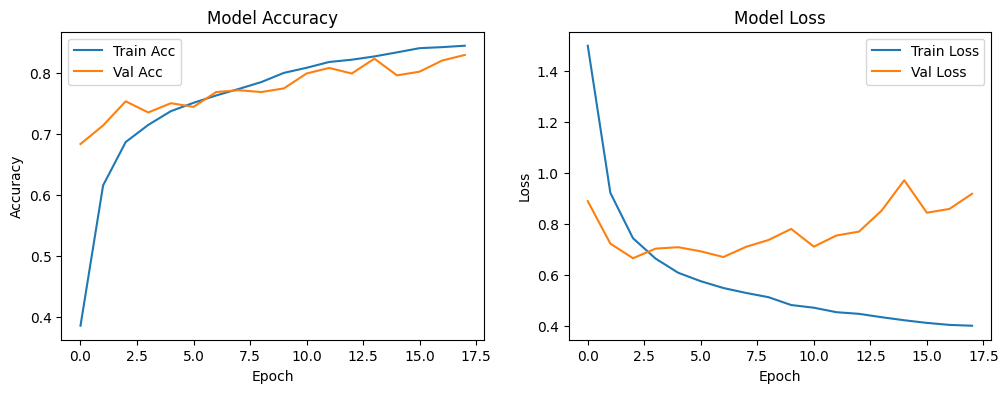

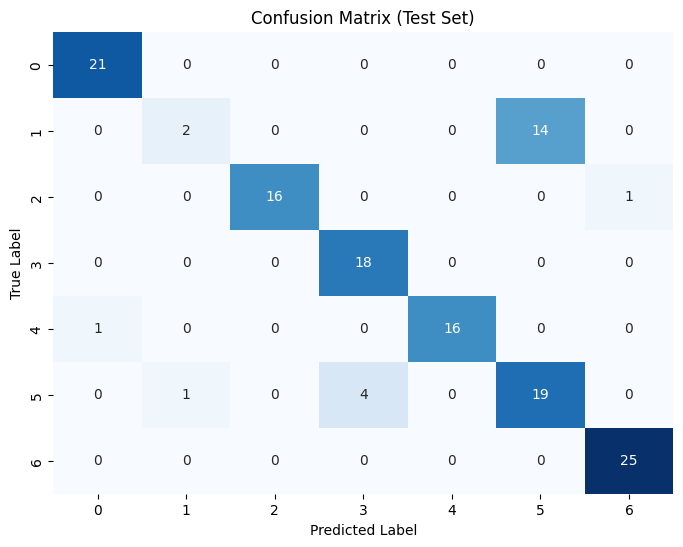

In [ ]:
import os
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ==========================================
# 1. 設定檔案路徑 (請確認這裡的檔名與你產生的檔案一致)
# ==========================================
TRAIN_DATA_PATH = 'rehab_dataset_keyframes_train_xyz.csv'
VAL_DATA_PATH   = 'rehab_dataset_keyframes_val_xyz.csv'
TEST_DATA_PATH  = 'rehab_dataset_keyframes_test_xyz.csv'

MODEL_SAVE_PATH = 'rehab_action_classifier_clear_2.h5'
NUM_CLASSES = 7

# 定義讀取資料的函式 (避免重複寫三次程式碼)
def load_dataset(path, name="Dataset"):
    if not os.path.exists(path):
        print(f"錯誤：找不到檔案 {path}")
        exit()
    
    print(f"正在讀取 {name} ({path})...")
    df = pd.read_csv(path, header=None)
    
    # 前 63 欄是特徵 (21點 * 3軸)，最後一欄是 Label
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values.astype(int) # 確保是整數
    
    # 修正標籤：如果是 1~7，轉成 0~6
    if np.min(y) == 1:
        y = y - 1
        
    return X, y

# ==========================================
# 2. 讀取資料
# ==========================================
X_train, y_train = load_dataset(TRAIN_DATA_PATH, "訓練集")
X_val, y_val     = load_dataset(VAL_DATA_PATH,   "驗證集")
X_test, y_test   = load_dataset(TEST_DATA_PATH,  "測試集")

print(f"\n資料載入完成:")
print(f"Training: {X_train.shape}, Validation: {X_val.shape}, Testing: {X_test.shape}")

# ==========================================
# 3. 數據增強 (只對訓練集做！)
# ==========================================
print("\n正在進行訓練集數據增強 (加入雜訊)...")

def add_noise(data, noise_level=0.02):
    noise = np.random.normal(0, noise_level, data.shape)
    return data + noise

# 擴充訓練資料：原始 + 加雜訊版本
X_train_noise = add_noise(X_train)
X_train_augmented = np.vstack((X_train, X_train_noise))
y_train_augmented = np.concatenate((y_train, y_train))

# 驗證集 (Val) 和 測試集 (Test) 不需要增強，保持原樣以反應真實情況

print(f"增強後訓練集筆數: {len(X_train_augmented)}")

# ==========================================
# 4. 建立模型
# ==========================================
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((63, )),
    # 原本 256 -> 改成 64 或 32
    tf.keras.layers.Dense(64, activation='relu'), 
    tf.keras.layers.Dropout(0.5), # Dropout 調高到 0.5 (強迫遺忘)
    # 原本 128 -> 改成 32 或 16
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    # 輸出層不變
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ==========================================
# 5. 開始訓練
# ==========================================
print("\n開始訓練...")

history = model.fit(
    X_train_augmented, y_train_augmented,  # 訓練用增強後的資料
    epochs=100,
    batch_size=64,
    validation_data=(X_val, y_val),        # 驗證用純淨的 Validation Set
    callbacks=[
        # 當 Validation Loss 連續 15 次沒下降就停止，並回朔到最好的參數
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', 
            patience=15, 
            verbose=1, 
            restore_best_weights=True
        )
    ]
)

# 儲存模型
model.save(MODEL_SAVE_PATH)
print(f"訓練完成！模型已儲存為: {MODEL_SAVE_PATH}")

# ==========================================
# 6. 模型評估 (使用 Test Set)
# ==========================================
print("\n正在使用測試集 (Test Set) 進行最終評估...")

# 這裡使用 X_test，這是模型完全沒看過的資料
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# A. 分類報告
print("\n--- 分類報告 (Classification Report) ---")
print(classification_report(y_test, y_pred, digits=4))

# B. 繪製訓練過程曲線 (Loss & Accuracy)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# C. 混淆矩陣
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

正在讀取 訓練集 (rehab_dataset_keyframes_train_xyz.csv)...
正在讀取 驗證集 (rehab_dataset_keyframes_val_xyz.csv)...
正在讀取 測試集 (rehab_dataset_keyframes_test_xyz.csv)...

資料載入完成:
Training: (25320, 63), Validation: (329, 63), Testing: (301, 63)

正在進行訓練集數據增強 (加入雜訊)...
增強後訓練集筆數: 50640

開始訓練...
Epoch 1/100
792/792 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7092 - loss: 0.7731 - val_accuracy: 0.8571 - val_loss: 0.4746
Epoch 2/100
792/792 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8993 - loss: 0.2823 - val_accuracy: 0.8632 - val_loss: 0.4472
Epoch 3/100
792/792 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9365 - loss: 0.1822 - val_accuracy: 0.8723 - val_loss: 0.5065
Epoch 4/100
792/792 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9538 - loss: 0.1339 - val_accuracy: 0.8906 - val_loss: 0.4789
Epoch 5/100
792/792 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9635 - loss: 0.1059 - val_accuracy: 0.8967 - val_loss: 0.4697
Epoch 6/100
792/792 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9706 - loss: 

訓練完成！模型已儲存為: rehab_action_classifier_clear_4.h5

正在使用測試集 (Test Set) 進行最終評估...
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

--- 分類報告 (Classification Report) ---
              precision    recall  f1-score   support

           0     0.8936    0.9333    0.9130        45
           1     0.7619    0.7805    0.7711        41
           2     0.8333    0.9783    0.9000        46
           3     0.8333    0.8333    0.8333        36
           4     0.9310    0.7297    0.8182        37
           5     0.8511    0.8000    0.8247        50
           6     0.9783    0.9783    0.9783        46

    accuracy                         0.8671       301
   macro avg     0.8689    0.8619    0.8627       301
weighted avg     0.8697    0.8671    0.8658       301



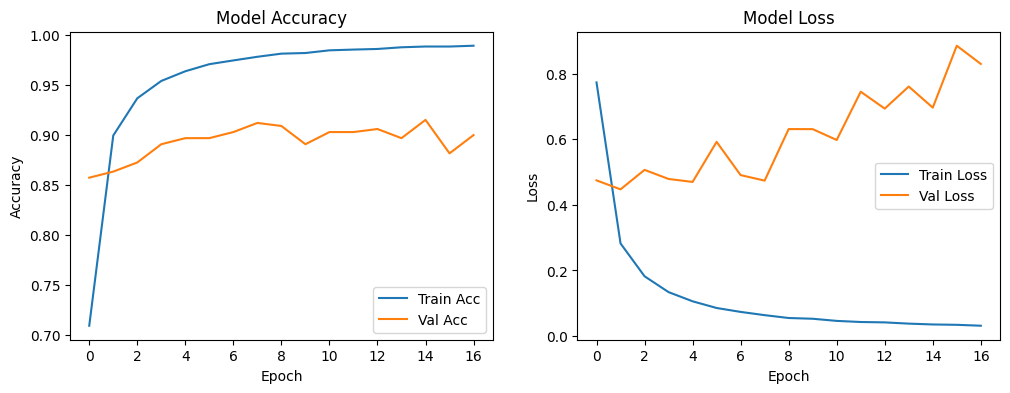

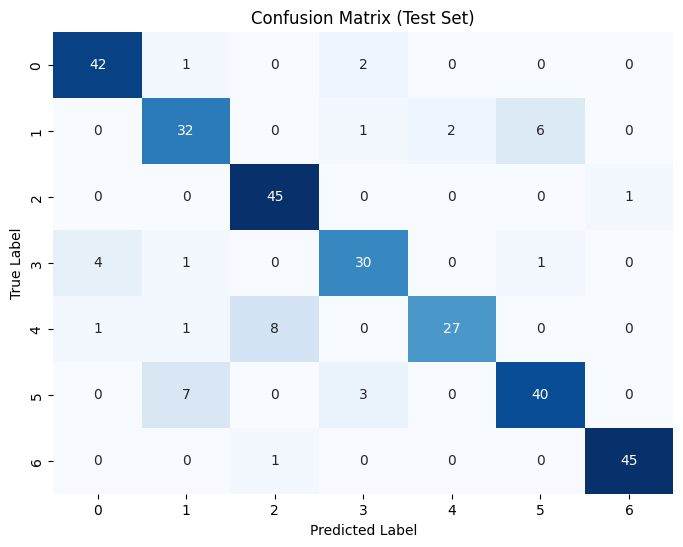

In [ ]:
import os
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ==========================================
# 1. 設定檔案路徑 (請確認這裡的檔名與你產生的檔案一致)
# ==========================================
TRAIN_DATA_PATH = 'rehab_dataset_keyframes_train_xyz.csv'
VAL_DATA_PATH   = 'rehab_dataset_keyframes_val_xyz.csv'
TEST_DATA_PATH  = 'rehab_dataset_keyframes_test_xyz.csv'

MODEL_SAVE_PATH = 'rehab_action_classifier_clear_4.h5'
NUM_CLASSES = 7

# 定義讀取資料的函式 (避免重複寫三次程式碼)
def load_dataset(path, name="Dataset"):
    if not os.path.exists(path):
        print(f"錯誤：找不到檔案 {path}")
        exit()
    
    print(f"正在讀取 {name} ({path})...")
    df = pd.read_csv(path, header=None)
    
    # 前 63 欄是特徵 (21點 * 3軸)，最後一欄是 Label
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values.astype(int) # 確保是整數
    
    # 修正標籤：如果是 1~7，轉成 0~6
    if np.min(y) == 1:
        y = y - 1
        
    return X, y

# ==========================================
# 2. 讀取資料
# ==========================================
X_train, y_train = load_dataset(TRAIN_DATA_PATH, "訓練集")
X_val, y_val     = load_dataset(VAL_DATA_PATH,   "驗證集")
X_test, y_test   = load_dataset(TEST_DATA_PATH,  "測試集")

print(f"\n資料載入完成:")
print(f"Training: {X_train.shape}, Validation: {X_val.shape}, Testing: {X_test.shape}")

# ==========================================
# 3. 數據增強 (只對訓練集做！)
# ==========================================
print("\n正在進行訓練集數據增強 (加入雜訊)...")

def add_noise(data, noise_level=0.02):
    noise = np.random.normal(0, noise_level, data.shape)
    return data + noise

# 擴充訓練資料：原始 + 加雜訊版本
X_train_noise = add_noise(X_train)
X_train_augmented = np.vstack((X_train, X_train_noise))
y_train_augmented = np.concatenate((y_train, y_train))
# 改成這樣：
# print("本次訓練不使用雜訊增強，專注於學習細微特徵...")
# X_train_augmented = X_train
# y_train_augmented = y_train

# 驗證集 (Val) 和 測試集 (Test) 不需要增強，保持原樣以反應真實情況

print(f"增強後訓練集筆數: {len(X_train_augmented)}")

# ==========================================
# 4. 建立模型
# ==========================================
# === 修改部分 4. 建立模型 ===
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((63, )),
    
    # 稍微增加一點第一層的神經元，讓它能捕捉更多特徵
    tf.keras.layers.Dense(128, activation='relu'), 
    tf.keras.layers.Dropout(0.2), # 降低 Dropout 到 0.2 (只丟棄 20%)
    
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2), # 降低 Dropout 到 0.2
    
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ==========================================
# 5. 開始訓練
# ==========================================
print("\n開始訓練...")

history = model.fit(
    X_train_augmented, y_train_augmented,  # 訓練用增強後的資料
    epochs=100,
    batch_size=64,
    validation_data=(X_val, y_val),        # 驗證用純淨的 Validation Set
    callbacks=[
        # 當 Validation Loss 連續 15 次沒下降就停止，並回朔到最好的參數
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', 
            patience=15, 
            verbose=1, 
            restore_best_weights=True
        )
    ]
)

# 儲存模型
model.save(MODEL_SAVE_PATH)
print(f"訓練完成！模型已儲存為: {MODEL_SAVE_PATH}")

# ==========================================
# 6. 模型評估 (使用 Test Set)
# ==========================================
print("\n正在使用測試集 (Test Set) 進行最終評估...")

# 這裡使用 X_test，這是模型完全沒看過的資料
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# A. 分類報告
print("\n--- 分類報告 (Classification Report) ---")
print(classification_report(y_test, y_pred, digits=4))

# B. 繪製訓練過程曲線 (Loss & Accuracy)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# C. 混淆矩陣
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

add_noise=0.01

正在讀取 訓練集 (rehab_dataset_keyframes_train_xyz.csv)...
正在讀取 驗證集 (rehab_dataset_keyframes_val_xyz.csv)...
正在讀取 測試集 (rehab_dataset_keyframes_test_xyz.csv)...

資料載入完成:
Training: (25320, 63), Validation: (329, 63), Testing: (301, 63)

正在進行訓練集數據增強 (加入雜訊)...
增強後訓練集筆數: 50640
Epoch 1/100
792/792 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7115 - loss: 0.9362 - val_accuracy: 0.8663 - val_loss: 0.6564
Epoch 2/100
792/792 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8949 - loss: 0.4824 - val_accuracy: 0.8875 - val_loss: 0.5535
Epoch 3/100
792/792 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9319 - loss: 0.3730 - val_accuracy: 0.9058 - val_loss: 0.5356
Epoch 4/100
792/792 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9502 - loss: 0.3152 - val_accuracy: 0.9149 - val_loss: 0.4875
Epoch 5/100
792/792 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9589 - loss: 0.2778 - val_accuracy: 0.9088 - val_loss: 0.4921
Epoch 6/100
792/792 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9639 - loss: 0.2530 - 

訓練完成！模型已儲存為: rehab_action_classifier_clear_8_332301.h5

正在使用測試集 (Test Set) 進行最終評估...
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

--- 分類報告 (Classification Report) ---
              precision    recall  f1-score   support

           0     0.9318    0.9111    0.9213        45
           1     0.8537    0.8537    0.8537        41
           2     0.9000    0.9783    0.9375        46
           3     0.8250    0.9167    0.8684        36
           4     0.9412    0.8649    0.9014        37
           5     0.9149    0.8600    0.8866        50
           6     0.9778    0.9565    0.9670        46

    accuracy                         0.9070       301
   macro avg     0.9063    0.9059    0.9051       301
weighted avg     0.9089    0.9070    0.9070       301



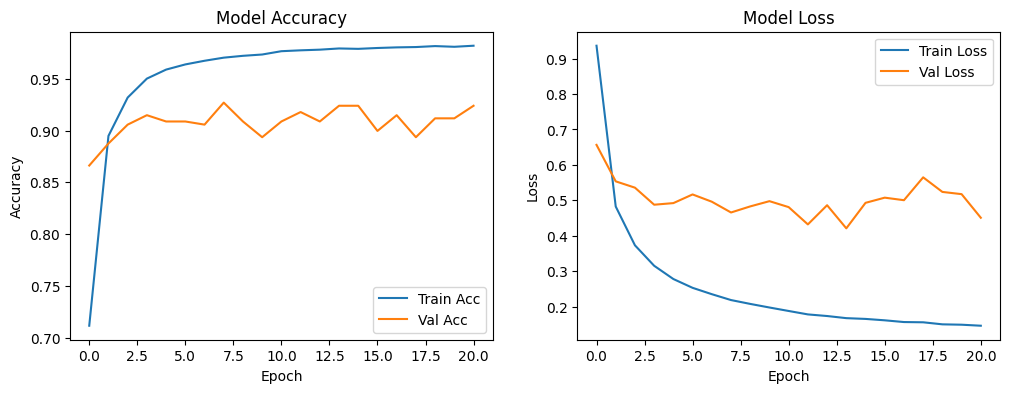

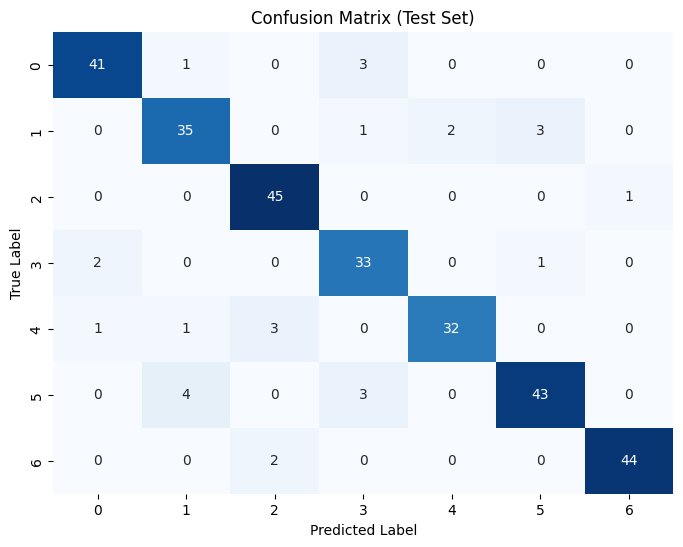

In [2]:
import os
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras import regularizers

# ==========================================
# 1. 設定檔案路徑 (請確認這裡的檔名與你產生的檔案一致)
# ==========================================
TRAIN_DATA_PATH = 'rehab_dataset_keyframes_train_xyz.csv'
VAL_DATA_PATH   = 'rehab_dataset_keyframes_val_xyz.csv'
TEST_DATA_PATH  = 'rehab_dataset_keyframes_test_xyz.csv'

MODEL_SAVE_PATH = 'rehab_action_classifier_clear_8_332301.h5'
NUM_CLASSES = 7

# 定義讀取資料的函式 (避免重複寫三次程式碼)
def load_dataset(path, name="Dataset"):
    if not os.path.exists(path):
        print(f"錯誤：找不到檔案 {path}")
        exit()
    
    print(f"正在讀取 {name} ({path})...")
    df = pd.read_csv(path, header=None)
    
    # 前 63 欄是特徵 (21點 * 3軸)，最後一欄是 Label
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values.astype(int) # 確保是整數
    
    # 修正標籤：如果是 1~7，轉成 0~6
    if np.min(y) == 1:
        y = y - 1
        
    return X, y

# ==========================================
# 2. 讀取資料
# ==========================================
X_train, y_train = load_dataset(TRAIN_DATA_PATH, "訓練集")
X_val, y_val     = load_dataset(VAL_DATA_PATH,   "驗證集")
X_test, y_test   = load_dataset(TEST_DATA_PATH,  "測試集")

print(f"\n資料載入完成:")
print(f"Training: {X_train.shape}, Validation: {X_val.shape}, Testing: {X_test.shape}")

# ==========================================
# 3. 數據增強 (只對訓練集做！)
# ==========================================
print("\n正在進行訓練集數據增強 (加入雜訊)...")

def add_noise(data, noise_level=0.01):
    noise = np.random.normal(0, noise_level, data.shape)
    return data + noise

# 擴充訓練資料：原始 + 加雜訊版本
X_train_noise = add_noise(X_train)
X_train_augmented = np.vstack((X_train, X_train_noise))
y_train_augmented = np.concatenate((y_train, y_train))
# 改成這樣：
# print("本次訓練不使用雜訊增強，專注於學習細微特徵...")
# X_train_augmented = X_train
# y_train_augmented = y_train

# 驗證集 (Val) 和 測試集 (Test) 不需要增強，保持原樣以反應真實情況

print(f"增強後訓練集筆數: {len(X_train_augmented)}")

# ==========================================
# 4. 建立模型
# ==========================================
# === 修改部分 4. 建立模型 ===
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((63, )),
    
    # 第一層：加入 L2 正則化，Dropout 微調至 0.3
    tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)), 
    tf.keras.layers.Dropout(0.2), 
    
    # 第二層：加入 L2 正則化，Dropout 微調至 0.3
    tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    tf.keras.layers.Dropout(0.2),
    
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), # 學習率維持 0.001
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# === 修改部分：Early Stopping ===
history = model.fit(
    X_train_augmented, y_train_augmented,
    epochs=100,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', 
            patience=7,             # 從 15 改成 7，一發現不對勁就早點停
            verbose=1, 
            restore_best_weights=True # 這行很重要，確保最後模型是存 Loss 最低的那一刻，而不是過擬合後的
        )
    ]
)

# 儲存模型
model.save(MODEL_SAVE_PATH)
print(f"訓練完成！模型已儲存為: {MODEL_SAVE_PATH}")

# ==========================================
# 6. 模型評估 (使用 Test Set)
# ==========================================
print("\n正在使用測試集 (Test Set) 進行最終評估...")

# 這裡使用 X_test，這是模型完全沒看過的資料
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# A. 分類報告
print("\n--- 分類報告 (Classification Report) ---")
print(classification_report(y_test, y_pred, digits=4))

# B. 繪製訓練過程曲線 (Loss & Accuracy)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# C. 混淆矩陣
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [2]:
# inference.py
# 鏡頭 微調3+7 2+6
import os
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

import cv2
import numpy as np
import tensorflow as tf
import mediapipe as mp
from PIL import Image, ImageDraw, ImageFont

# ==========================================
# 0. 設定區 (參數微調區)
# ==========================================
# 請修改為你的模型路徑
MODEL_PATH = 'rehab_action_classifier_clear_8_332301.h5' 

# 【重要】必須設為 True 才能使用深度判斷
USE_Z_AXIS = True 

# 信心度門檻
CONFIDENCE_THRESHOLD = 0.95

# --- [幾何門檻 1] 拇指彎曲 vs 手指伸展 ---
# 距離 > 此值 -> 判定為張開
# 距離 < 此值 -> 判定為彎曲
# 建議值約 0.15 ~ 0.3 (視你的正規化縮放而定，0.6 可能有點太大)
THUMB_DIST_THRESHOLD = 0.6 

# --- [幾何門檻 2] 拇指外握 vs 拇指內握 (新增) ---
# 這是 "拇指尖 Z" - "食指根部 Z" 的差值
# 拇指在外：拇指較凸 (靠近鏡頭)，Z值較小 -> 差值為負 (例如 -0.05)
# 拇指在內：拇指被包住 (遠離鏡頭)，Z值較大 -> 差值接近 0 或正數
# 建議值：-0.02 (比這個值更負就是外握，否則內握)
Z_DIFF_THRESHOLD = -0.02

GESTURE_LABELS = {
    0: "Hook 勾拳",             
    1: "Angry Fist 生氣握拳",    # [拇指在外]
    2: "Thumb Flex 拇指彎曲",    
    3: "Straight Fist 直拳",     
    4: "The Duck 鴨子",          
    5: "Thumb In Fist 拇指內握", # [拇指在內]
    6: "Spread Hand 手指伸展",   
    7: "Unknown (信心不足)"       
}

# ==========================================
# 1. 載入模型與 MediaPipe
# ==========================================
try:
    model = tf.keras.models.load_model(MODEL_PATH)
    print(f"成功載入模型: {MODEL_PATH}")
    input_shape = model.input_shape[1]
    
    if USE_Z_AXIS and input_shape == 42:
        print("警告：設定 USE_Z_AXIS=True，但模型是 2D。自動切換回 False。")
        USE_Z_AXIS = False
    elif not USE_Z_AXIS and input_shape == 63:
        print("警告：設定 USE_Z_AXIS=False，但模型是 3D。自動切換回 True。")
        USE_Z_AXIS = True

except Exception as e:
    print(f"載入模型失敗: {e}")
    exit()

mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils
hands = mp_hands.Hands(
    max_num_hands=1,
    min_detection_confidence=0.7,
    min_tracking_confidence=0.5
)

# ==========================================
# 2. 核心：前處理
# ==========================================
def normalize_landmarks(lm):
    if USE_Z_AXIS:
        wrist = np.array([lm[0].x, lm[0].y, lm[0].z])
        pts = np.array([[p.x, p.y, p.z] for p in lm])
    else:
        wrist = np.array([lm[0].x, lm[0].y])
        pts = np.array([[p.x, p.y] for p in lm])

    pts = pts - wrist
    middle_finger_len = np.linalg.norm(pts[9][:2]) 
    scale = max(middle_finger_len, 1e-6)
    pts = pts / scale

    angle = -np.arctan2(pts[9][1], pts[9][0])
    c, s = np.cos(angle), np.sin(angle)
    
    if USE_Z_AXIS:
        R = np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]])
    else:
        R = np.array([[c, -s], [s, c]])
        
    pts = pts.dot(R.T)
    return pts

# ==========================================
# 3. 輔助：中文顯示
# ==========================================
def cv2_img_add_text(img, text, left, top, text_color=(0, 255, 0), text_size=20):
    if (isinstance(img, np.ndarray)):
        img = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    draw = ImageDraw.Draw(img)
    try:
        fontStyle = ImageFont.truetype("msjh.ttc", text_size, encoding="utf-8")
    except:
        fontStyle = ImageFont.load_default()
    draw.text((left, top), text, fill=text_color, font=fontStyle)
    return cv2.cvtColor(np.asarray(img), cv2.COLOR_RGB2BGR)

# ==========================================
# 4. 主迴圈
# ==========================================
cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)

print("程式啟動中... 按 'q' 鍵離開")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret: break

    frame = cv2.flip(frame, 1)
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = hands.process(rgb_frame)
    
    if results.multi_hand_landmarks:
        for hand_landmarks, handedness in zip(results.multi_hand_landmarks, results.multi_handedness):
            
            mp_drawing.draw_landmarks(frame, hand_landmarks, mp_hands.HAND_CONNECTIONS)
            
            # 1. 前處理
            pts = normalize_landmarks(hand_landmarks.landmark)
            
            # 2. 鏡像修正
            label_name = handedness.classification[0].label
            if label_name == "Left":
                pts[:, 0] = -pts[:, 0]

            # 3. 預測
            input_data = pts.flatten().tolist()
            input_data = np.expand_dims(input_data, axis=0)
            
            prediction = model.predict(input_data, verbose=0)
            class_id = np.argmax(prediction)
            confidence = np.max(prediction)
            
            # ==========================================
            # 邏輯判斷區
            # ==========================================
            final_class_id = class_id
            debug_msg = ""

            # --- A. 信心度過濾 ---
            if confidence < CONFIDENCE_THRESHOLD:
                #final_class_id = 7 # Unknown
                print(" ")
            
            # --- B. 規則 1: 拇指彎曲 vs 手指伸展 ---
            # Index 2 (Thumb Flex) vs Index 6 (Spread Hand)
            elif final_class_id == 2 or final_class_id == 6:
                # thumb_tip = pts[4]
                # pinky_mcp = pts[17]
                # dist = np.linalg.norm(thumb_tip - pinky_mcp)
                # debug_msg = f"Dist: {dist:.3f}" 
                
                # if dist > THUMB_DIST_THRESHOLD:
                #     final_class_id = 6 
                # else:
                #     final_class_id = 2 
                print(" ")

            # --- C. 規則 2: 拇指外握(生氣) vs 拇指內握 ---
            # Index 1 (Angry Fist) vs Index 5 (Thumb In Fist)
            # 也可以把 Index 0 (Hook) 加進來一起判斷，如果 Hook 也是外握的話
            elif final_class_id == 1 or final_class_id == 5 or final_class_id == 0:
                # thumb_tip = pts[4]   # 拇指尖
                # index_pip = pts[6]   # 食指第二關節
                
                # # 計算 Z 軸差值 (負越小代表越凸出/靠近鏡頭)
                # z_diff = thumb_tip[2] - index_pip[2]
                # debug_msg = f"Z-Diff: {z_diff:.3f}"

                # # 判定邏輯
                # if z_diff < Z_DIFF_THRESHOLD:
                #     # 拇指明顯在外
                #     if final_class_id == 5: # 如果原本猜內握，強制改成外握(生氣)
                #         final_class_id = 1 
                # else:
                #     # 拇指不夠凸出 (被包住或平行) -> 判定為內握
                #     final_class_id = 5 
                print(" ")

            # ==========================================

            # 顯示
            result_text = GESTURE_LABELS.get(final_class_id, "Unknown")
            
            if final_class_id == 7:
                color = (0, 0, 255) 
                display_text = f"Unknown ({confidence:.2f})"
            else:
                color = (0, 255, 0)
                display_text = f"{result_text} ({confidence:.2f}) {debug_msg}"

            text_x = int(hand_landmarks.landmark[0].x * frame.shape[1])
            text_y = int(hand_landmarks.landmark[0].y * frame.shape[0])
            
            frame = cv2_img_add_text(frame, display_text, text_x + 10, text_y - 40, color, 30)

    cv2.imshow('Rehab Gesture Recognition', frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

成功載入模型: rehab_action_classifier_clear_8_332301.h5
程式啟動中... 按 'q' 鍵離開
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
